# Arquivo criado para realizar uma das sugestões de análise do README.
"Veja a evolução ao longo dos anos (2020 a 2024) de uma função para Maceió e compare com a média das capitais."

Neste caso, a função escolhida foi a 23 - Comércio e Serviços.

In [8]:
import pandas as pd
from pathlib import Path

# Encontrando o arquivo
raiz_do_projeto = Path.cwd().parent
caminho_db = raiz_do_projeto / "dados_otimizados" / "dados_otimizados.parquet"

# Lendo o arquivo
df = pd.read_parquet(caminho_db)

In [9]:
# Removendo a notação científica nos valores numéricos do Jupyter Notebook
pd.set_option('display.float_format', '{:,.2f}'.format)

In [10]:
# Serão necessárias as colunas Conta, UF, Coluna, Função/Subfunção e Ano

df_filtrado = df[["Conta", "UF", "Coluna", "Valor", "Função/Subfunção", "Ano"]]

# Condições de filtro
condicao_funcao = df_filtrado["Função/Subfunção"] == "Função"
condicao_estagios = df_filtrado["Coluna"].isin(["Despesas Empenhadas", "Despesas Pagas"])

# Aplicando os filtros
df_analise = df_filtrado[condicao_funcao & condicao_estagios]


In [11]:
# Tabela dinâmica para agrupar os dados.
df_pivot = pd.pivot_table(
    df_analise, 
    index=["Conta", "UF", "Ano"],
    columns="Coluna",
    values="Valor",
    aggfunc="sum"
    ).reset_index()


In [12]:
# Adicionando uma coluna para calcular a diferença entre Despesas Empenhadas e Despesas Pagas
df_pivot["Empenhado x Pago"] = df_pivot["Despesas Empenhadas"] - df_pivot["Despesas Pagas"]


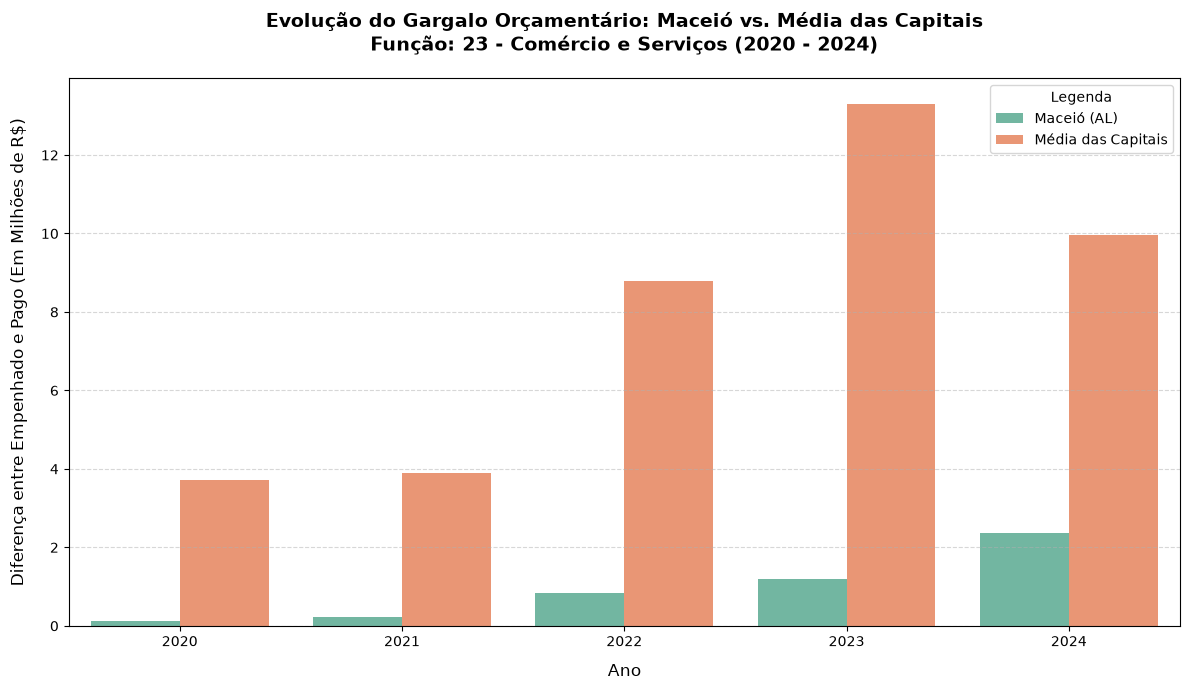

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparação e filtragem dos dados

# Definindo os parâmetros da nossa análise
funcao_alvo = "23 - Comércio e Serviços"
anos_analise = [2020, 2021, 2022, 2023, 2024]

# Filtrando a base mãe para conter apenas a função e os anos desejados
df_funcao = df_pivot[
    (df_pivot["Conta"] == funcao_alvo) & 
    (df_pivot["Ano"].isin(anos_analise))
].copy()

# 2. Definição de variáveis para Maceió a média das capitais

# Variável 1: Isolando os dados específicos de Maceió (AL)
df_maceio = df_funcao[df_funcao["UF"] == "AL"][["Ano", "Empenhado x Pago"]].copy()
df_maceio["Tipo"] = "Maceió (AL)"

# Variável 2: Calculando a média de todas as capitais ano a ano
df_media_capitais = df_funcao.groupby("Ano")["Empenhado x Pago"].mean().reset_index()
df_media_capitais["Tipo"] = "Média das Capitais"

# Juntando as duas visões em um único DataFrame
df_comparacao = pd.concat([df_maceio, df_media_capitais], ignore_index=True)

# Convertendo a diferença orçamentária para Milhões (R$)
df_comparacao["Milhões (R$)"] = df_comparacao["Empenhado x Pago"] / 1_000_000

# 3. Construção do gráfico
plt.figure(figsize=(12, 7))

sns.barplot(
    data=df_comparacao,
    x="Ano",
    y="Milhões (R$)",
    hue="Tipo",
    palette="Set2"
)

# Estilização do gráfico
plt.title(
    f"Evolução do Gargalo Orçamentário: Maceió vs. Média das Capitais\nFunção: {funcao_alvo} (2020 - 2024)", 
    fontsize=14, 
    fontweight='bold', 
    pad=20
)
plt.xlabel("Ano", fontsize=12, labelpad=10)
plt.ylabel("Diferença entre Empenhado e Pago (Em Milhões de R$)", fontsize=12, labelpad=10)

# Ativando linhas de grade horizontais para facilitar a leitura dos valores
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Ajustando a legenda para não cobrir as barras
plt.legend(title="Legenda")
plt.tight_layout()

# Exibindo o resultado final
plt.show()